In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("/content/covid_toy.csv")

In [3]:
data.sample(5)

,age,gender,fever,cough,city,has_covid
5,84,Female,NaN,Mild,Bangalore,Yes
36,38,Female,101.0,Mild,Bangalore,No
67,65,Male,99.0,Mild,Bangalore,No
64,42,Male,104.0,Mild,Mumbai,No
38,49,Female,101.0,Mild,Delhi,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        100 non-null    int64  
 1   gender     100 non-null    object 
 2   fever      90 non-null     float64
 3   cough      100 non-null    object 
 4   city       100 non-null    object 
 5   has_covid  100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [5]:
data["gender"].value_counts()

,count
gender,
Female,59
Male,41


In [6]:
data["cough"].value_counts()

,count
cough,
Mild,62
Strong,38


In [7]:
data["city"].value_counts()

,count
city,
Kolkata,32
Bangalore,30
Delhi,22
Mumbai,16


In [23]:
X_train, X_test, y_train, y_test = train_test_split(data.drop("has_covid",axis=1),data["has_covid"],test_size=0.2,random_state=32)

# **Column Transformer**

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

transformer = ColumnTransformer(transformers=[
    ("tnf1", SimpleImputer(), ["fever"]),
    ("tnf2", OneHotEncoder(sparse_output=False, drop="first", dtype=int), ["gender","city"]),
    ("tnf3", OrdinalEncoder(categories=[["Mild","Strong"]]), ["cough"])
], remainder="passthrough")

In [24]:
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [25]:
columns = transformer.get_feature_names_out()

In [26]:
X_train = pd.DataFrame(X_train, columns = columns)

In [27]:
X_train.sample(5)

,tnf1__fever,tnf2__gender_Male,tnf2__city_Delhi,tnf2__city_Kolkata,tnf2__city_Mumbai,tnf3__cough,remainder__age
11,98.000000,1.0,0.0,0.0,0.0,0.0,73.0
68,101.000000,0.0,0.0,0.0,1.0,0.0,65.0
41,98.000000,1.0,0.0,1.0,0.0,0.0,24.0
77,100.942857,0.0,0.0,0.0,0.0,0.0,84.0
44,100.000000,1.0,0.0,0.0,0.0,0.0,11.0


# **Pipelines**

In [111]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

In [39]:
data = pd.read_csv("train.csv")

In [40]:
data.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
362,363,0,3,"Barbara, Mrs. (Catherine David)",female,45.0,0,1,2691,14.4542,NaN,C
233,234,1,3,"Asplund, Miss. Lillian Gertrud",female,5.0,4,2,347077,31.3875,NaN,S
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0000,NaN,S
369,370,1,1,"Aubart, Mme. Leontine Pauline",female,24.0,0,0,PC 17477,69.3000,B35,C
580,581,1,2,"Christy, Miss. Julie Rachel",female,25.0,1,1,237789,30.0000,NaN,S


In [43]:
data = data.drop(["PassengerId","Name","Ticket","Cabin"],axis=1)

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [45]:
data.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [46]:
data["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [47]:
data["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [48]:
data["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [49]:
X_train, X_test, y_train, y_test = train_test_split(data.drop("Survived",axis=1),data["Survived"],test_size=0.2,random_state=32)

In [53]:
X_train.sample(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
806,1,male,39.0,0,0,0.0000,S
485,3,female,NaN,3,1,25.4667,S
123,2,female,32.5,0,0,13.0000,S
397,2,male,46.0,0,0,26.0000,S
337,1,female,41.0,0,0,134.5000,C


In [54]:
# It is better to identify columns in ColumnTransformer by their indices and not by their names in pipelines to avoid future endpoint conflicts

In [68]:
preprocessor = ColumnTransformer(transformers=[
    ("numerical", Pipeline([
        ("imputer",SimpleImputer(strategy="mean")),
        ("scaler", MinMaxScaler())
    ]), [0,2,3,4,5]),
    ("categorical", Pipeline([
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(sparse_output=False, drop="first", dtype=int))
    ]),[1,6])
], remainder="passthrough")

In [69]:
pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("selector", SelectKBest(score_func=chi2, k=8)),
    ("model",DecisionTreeClassifier())
])

In [70]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  [0, 2, 3, 4, 5]),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 dtype=<class 'int'>,
                                                                                 sparse_output=False))]),
                                                  [1, 6])])),
                ('selector',
                 SelectKBest(k=8,
                             score_func=<function chi2 at 0x7bc7a41642c0>)),
                ('model', DecisionTreeClassifier())])

In [72]:
pipeline.named_steps

{'preprocessor': ColumnTransformer(remainder='passthrough',
                   transformers=[('numerical',
                                  Pipeline(steps=[('imputer', SimpleImputer()),
                                                  ('scaler', MinMaxScaler())]),
                                  [0, 2, 3, 4, 5]),
                                 ('categorical',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('encoder',
                                                   OneHotEncoder(drop='first',
                                                                 dtype=<class 'int'>,
                                                                 sparse_output=False))]),
                                  [1, 6])]),
 'selector': SelectKBest(k=8, score_func=<function chi2 at 0x7bc7a41642c0>),
 'model': DecisionTreeClassifier()}

In [77]:
pipeline.named_steps["preprocessor"].transformers_

[('numerical',
  Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', MinMaxScaler())]),
  [0, 2, 3, 4, 5]),
 ('categorical',
  Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                  ('encoder',
                   OneHotEncoder(drop='first', dtype=<class 'int'>,
                                 sparse_output=False))]),
  [1, 6])]

In [82]:
num_pipeline = [t for t in preprocessor.transformers_ if t[0] == "numerical"][0][1]
cat_pipeline = [t for t in preprocessor.transformers_ if t[0] == "categorical"][0][1]

In [86]:
num_pipeline.named_steps["imputer"]

SimpleImputer()

In [87]:
num_pipeline.named_steps["scaler"]

MinMaxScaler()

In [88]:
cat_pipeline.named_steps["imputer"]

SimpleImputer(strategy='most_frequent')

In [89]:
cat_pipeline.named_steps["encoder"]

OneHotEncoder(drop='first', dtype=<class 'int'>, sparse_output=False)

In [91]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['numerical__Pclass', 'numerical__Age', 'numerical__SibSp',
       'numerical__Parch', 'numerical__Fare', 'categorical__Sex_male',
       'categorical__Embarked_Q', 'categorical__Embarked_S'], dtype=object)

In [95]:
num_pipeline["imputer"].statistics_

array([ 2.30617978, 29.80285714,  0.53932584,  0.39185393, 31.44119199])

In [98]:
print(num_pipeline["scaler"].data_min_)
print(num_pipeline["scaler"].data_max_)
print(num_pipeline["scaler"].data_range_)

[1.   0.42 0.   0.   0.  ]
[  3.      80.       8.       5.     512.3292]
[  2.      79.58     8.       5.     512.3292]


In [99]:
cat_pipeline.named_steps["imputer"].statistics_

array(['male', 'S'], dtype=object)

In [101]:
cat_pipeline.named_steps["encoder"].categories_

[array(['female', 'male'], dtype=object), array(['C', 'Q', 'S'], dtype=object)]

In [106]:
pipeline.named_steps["model"].feature_importances_

array([0.0916461 , 0.26760941, 0.06699935, 0.04196552, 0.20628943,
       0.30028131, 0.00943302, 0.01577586])

In [108]:
y_pred = pipeline.predict(X_test)

In [112]:
confusion_matrix(y_test,y_pred)

array([[86, 22],
       [23, 48]])

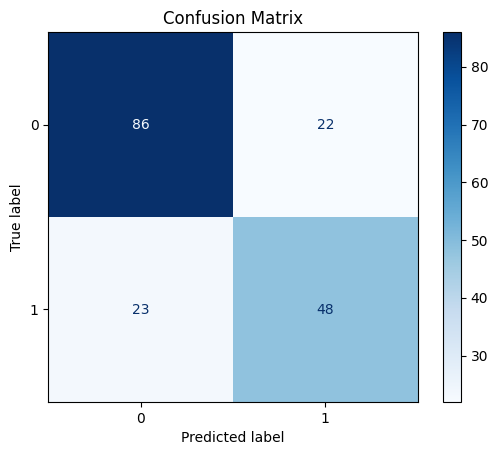

In [115]:
ConfusionMatrixDisplay.from_estimator(
    pipeline,
    X_test,
    y_test,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

In [116]:
accuracy_score(y_test,y_pred)

0.7486033519553073

In [117]:
# Exporting pipeline
import pickle
pickle.dump(pipeline, open("pipeline.pkl","wb"))

In [122]:
# Testing
import pickle
pipe = pickle.load(open("pipeline.pkl","rb"))

test_input = np.array([2,"male",18.0, 0, 0, 10.5, "S"],dtype="object").reshape(1,7)
test_input_2 = np.array([3,"female",25.0, 0, 0, 15, "S"],dtype="object").reshape(1,7)

print(pipe.predict(test_input))
print(pipe.predict(test_input_2))

[0]
[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
